### pyTRACK workflow for generic climate data

In [1]:
import os
notebook_path = os.getcwd()
print(notebook_path)

from track_wrapper import *

/home/requiem/pyTRACK-CMIP6/examples


In [2]:
# delete_case('example')

In [3]:
print(os.getcwd())
# case=Case('example', notebook_path+'/output', notebook_path+'/uv_test.nc')
case=Case('example', restart=True)
get_case()

/home/requiem/pyTRACK-CMIP6/examples
example


In [4]:
case.format()

Formatting input files and saving to /home/requiem/pyTRACK-CMIP6/examples/output/data


In [5]:
case.track()

Running track and outputting to /home/requiem/pyTRACK-CMIP6/examples/output/track
input file for wind is:  /home/requiem/pyTRACK-CMIP6/examples/output/data/uv_merged.nc
Starting preprocessing.
Remove unnecessary variables.


rm: cannot remove '/home/requiem/pyTRACK-CMIP6/examples/output/data/uv_merged.nc': No such file or directory


Regridded to n80 Gaussian grid.
Linking data to TRACK/indat
Years:  ['25']
Running TRACK for year: 25...
Splitting: 25
***INFORMATION***, data file:-                              
                   /home/requiem//TRACK/indat/uv_processed_25.nc                                       
                   exists and will be opened for data input.

do you want to load a country map, 'y' or 'n'
do you want to use an existing initialization, '0' for no, '1' for yes

File /home/requiem//TRACK/outdat/initial.y25 
 opened for 'w'

what format is the data
Input '0' for UNIX binary format       
Input '1' for standard ASCII format.   
Input '2' for UTF format.              
Input '3' for Met. Office PP format.   
Input '4' for NETCDF.                  

Print file summary information, 'y' or 'n'

Use netcdf id's or variable names and dimension values, input '0' or '1'

Is the data organized according to the COARDS convention, 'y' or 'n'

Available fields are:-   

Field Id. 3 is ua  
Field Id. 4 i

ssh: connect to host ic-czc43070lq port 22: Connection refused
mkdir: cannot create directory ‘/home/requiem/pyTRACK-CMIP6/examples/output/track/NH_25/DJF_MAX_1’: File exists


0.5u 0.0s 0:00.59 93.2% 0+0k 32680+7728io 184pf+0w


rm: cannot remove '/home/requiem/TRACK/outdat/throut.y25': No such file or directory
mkdir: cannot create directory ‘/home/requiem/pyTRACK-CMIP6/examples/output/track/NH_25/DJF_MIN_1’: File exists


0.7u 0.0s 0:00.81 96.2% 0+0k 16712+7736io 100pf+0w
Turning track output to netCDF...


rm: cannot remove '/home/requiem/TRACK/outdat/throut.y25': No such file or directory
rm: No match.
rm: cannot remove '/home/requiem/TRACK/outdat/idump.y25': No such file or directory
rm: cannot remove '/home/requiem/TRACK/outdat/throut.y25': No such file or directory
rm: cannot remove '/home/requiem/TRACK/outdat/objout.y25': No such file or directory
mv: cannot stat '/home/requiem/TRACK/outdat/user_tavg.y25': No such file or directory
mv: cannot stat '/home/requiem/TRACK/outdat/user_tavg.y25_var': No such file or directory
mv: cannot stat '/home/requiem/TRACK/outdat/user_tavg.y25_varfil': No such file or directory
mv: cannot stat '/home/requiem/TRACK/outdat/tr_grid.y25': No such file or directory
mv: cannot stat '/home/requiem/TRACK/outdat/tr_grid.y25': No such file or directory
rm: cannot remove '/home/requiem/TRACK/.run_at.lock.y25': No such file or directory
gzip: /home/requiem/pyTRACK-CMIP6/examples/output/track/NH_25/DJF_MIN_1/tdump.gz already exists;	not overwritten
gzip: /home/r

***INFORMATION***, there are no additional fields associated with this track data.

****INFORMATION****, number of tracks is 50
****INFORMATION****, writing netcdf file /home/requiem/pyTRACK-CMIP6/examples/output/track/NH_25/ff_trs_pos.nc
***INFORMATION***, there are no additional fields associated with this track data.

****INFORMATION****, number of tracks is 52
****INFORMATION****, writing netcdf file /home/requiem/pyTRACK-CMIP6/examples/output/track/NH_25/ff_trs_neg.nc
***INFORMATION***, there are no additional fields associated with this track data.

****INFORMATION****, number of tracks is 236
****INFORMATION****, writing netcdf file /home/requiem/pyTRACK-CMIP6/examples/output/track/NH_25/tr_trs_pos.nc
***INFORMATION***, there are no additional fields associated with this track data.

****INFORMATION****, number of tracks is 293
****INFORMATION****, writing netcdf file /home/requiem/pyTRACK-CMIP6/examples/output/track/NH_25/tr_trs_neg.nc


In [6]:
case.stats()

Running combined stats and outputting to /home/requiem/pyTRACK-CMIP6/examples/output/stats
***WARNING***, file /home/requiem//TRACK/indat/linux                              
               does not exist, input a valid filname
               possibly with full path.               

***INFORMATION***, data file:-                              
                   indat/gridT63.nc                                       
                   exists and will be opened for data input.

do you want to load a country map, 'y' or 'n'
do you want to use an existing initialization, '0' for no, '1' for yes

File /home/requiem//TRACK/outdat/initial.linux 
 opened for 'w'

what format is the data
Input '0' for UNIX binary format       
Input '1' for standard ASCII format.   
Input '2' for UTF format.              
Input '3' for Met. Office PP format.   
Input '4' for NETCDF.                  

Print file summary information, 'y' or 'n'

Use netcdf id's or variable names and dimension values, input '0' o

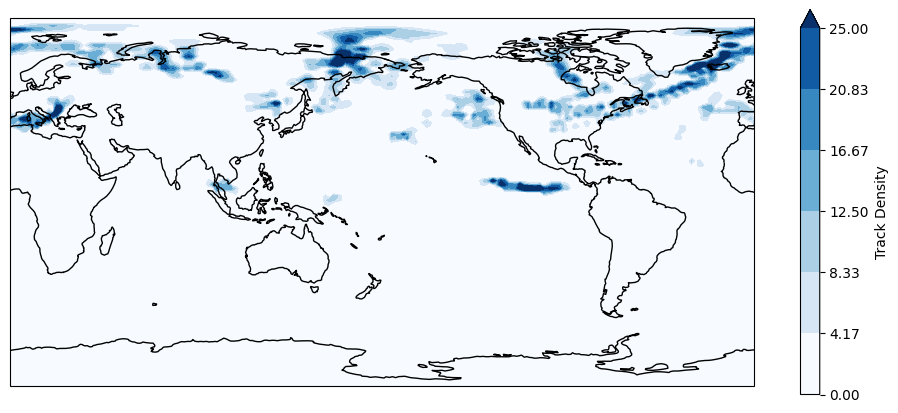

In [7]:
import xarray as xr
import matplotlib.pyplot as plt
import cartopy.crs as ccrs

stats=xr.open_dataset(notebook_path+'/output/stats/stats_combined.nc')

fig = plt.figure(figsize=(12,5))
    
ax = fig.add_subplot(111,projection=ccrs.PlateCarree(central_longitude=180))
ax.coastlines()

stats['tden'].plot.contourf(vmax=25, transform=ccrs.PlateCarree(), cmap='Blues')

Running cyclone composite


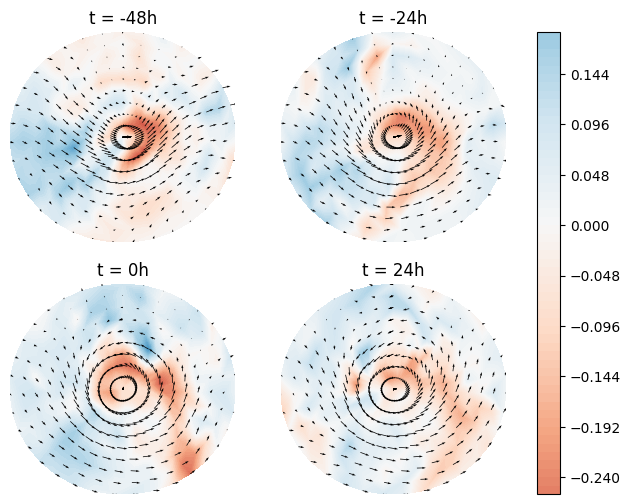

In [8]:
case.composite()

In [9]:
# import xarray as xr
# dat=xr.open_dataset(notebook_path+'/dec.nc')
# dat_tr=dat[['U', 'V', 'OMEGA']].isel({'time':slice(0,40)}).sel({'plev':[85000]})
# # dat_tr
# dat_tr.to_netcdf(notebook_path+'/uv_test.nc')